que las imágenes las tenías cargadas en tu drive pero dejas el link del kaggle en el README

As mentioned in the README, the dataset can be downloaded in the Kaggle link there mentioned

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# --- Section 1: loading the dataset and setting up the file paths and parameters ---

In [ ]:
#Unzipping the zipped folder that contains the 4 subfolders with the dementia images
!unzip "/content/drive/MyDrive/Mis estudios/BBS/Woxsen/dementia.zip" -d /content/dataset


Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_102.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_103.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_104.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_105.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_106.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_107.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_108.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_109.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_110.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_111.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_112.jpg  
  inflating: /c

In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime


In [ ]:



# IMPORTANT: Change this path to the location of your dataset folder
# The folder should contain the four sub-folders: "Mild Dementia", "Moderate Dementia", etc.
data_dir = '/content/dataset/Data'

# Define image dimensions and batch size
img_height, img_width = 224, 224
batch_size = 32
epochs = 10


In [ ]:
#This is for checking if the unzipping was performed properly.
import os
os.listdir(data_dir)


['Very mild Dementia', 'Mild Dementia', 'Moderate Dementia', 'Non Demented']

# --- Section 2: Data Loading and Preprocessing ---

In [ ]:
# Use ImageDataGenerator for data augmentation and preprocessing.
# This helps the model generalize better and prevents overfitting, which is
# very important for medical image datasets that may be small.
datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values to [0, 1]
    rotation_range=20,     # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2, # Randomly shift images horizontally
    height_shift_range=0.2,# Randomly shift images vertically
    horizontal_flip=True,  # Randomly flip images horizontally
    validation_split=0.2   # Reserve 20% of the data for validation
)

# Load training data from the directory structure
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Load validation data
validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Get the class names and number of classes from the generators
class_names = list(train_generator.class_indices.keys())
print("Class labels:", class_names)
num_classes = len(class_names)

Found 69151 images belonging to 4 classes.
Found 17286 images belonging to 4 classes.
Class labels: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


# --- Section 3: Build the Multi-Layer CNN Model ---

In [ ]:

model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Third Convolutional Block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 3D output to 1D for the dense layers
    Flatten(),

    # Fully Connected Layers
    Dense(512, activation='relu'),
    Dropout(0.5), # Dropout layer to reduce overfitting

    # Final output layer with SoftMax activation for multi-class classification
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# --- Section 4: Compile and Train the Model ---

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Appropriate loss function for multi-class problems
    metrics=['accuracy']
)

# Print a summary of the model architecture
model.summary()

# --- Checkpoint Callback ---
# Guardará el mejor modelo según la validación
checkpoint_filepath = "alzheimers_checkpoint.h5"

checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,   # guarda todo el modelo (estructura + pesos)
    monitor="val_accuracy",    # criterio de evaluación
    mode="max",
    save_best_only=True,       # solo guarda cuando mejora
    verbose=1
)

# Train the model using the data generators with checkpoint
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[checkpoint]
)

print(f"\nEntrenamiento finalizado. El mejor modelo se guardó en: {checkpoint_filepath}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,398,148 (169.37 MB)

 Trainable params: 44,398,148 (169.37 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.7741 - loss: 0.6582
Epoch 1: val_accuracy improved from -inf to 0.75975, saving model to alzheimers_checkpoint.h5


2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1091s 501ms/step - accuracy: 0.7741 - loss: 0.6582 - val_accuracy: 0.7597 - val_loss: 0.5438
Epoch 2/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.7869 - loss: 0.4945
Epoch 2: val_accuracy did not improve from 0.75975
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1055s 488ms/step - accuracy: 0.7869 - loss: 0.4945 - val_accuracy: 0.7551 - val_loss: 0.5312
Epoch 3/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.7947 - loss: 0.4763
Epoch 3: val_accuracy did not improve from 0.75975
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1046s 484ms/step - accuracy: 0.7947 - loss: 0.4763 - val_accuracy: 0.7571 - val_loss: 0.5489
Epoch 4/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8036 - loss: 0.4602
Epoch 4: val_accuracy did not improve from 0.75975
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1046s 484ms/step - accuracy: 0.8036 - loss: 0.4602 - val_accuracy: 0.7518 - val_loss: 0.5216
Epoch 5/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8087 - loss

2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1069s 495ms/step - accuracy: 0.8087 - loss: 0.4401 - val_accuracy: 0.7655 - val_loss: 0.5817
Epoch 6/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8136 - loss: 0.4312
Epoch 6: val_accuracy did not improve from 0.76553
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1063s 492ms/step - accuracy: 0.8136 - loss: 0.4312 - val_accuracy: 0.7610 - val_loss: 0.5188
Epoch 7/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.8215 - loss: 0.4128
Epoch 7: val_accuracy did not improve from 0.76553
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1060s 490ms/step - accuracy: 0.8215 - loss: 0.4128 - val_accuracy: 0.7581 - val_loss: 0.5362
Epoch 8/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8323 - loss: 0.3996
Epoch 8: val_accuracy did not improve from 0.76553
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1067s 494ms/step - accuracy: 0.8323 - loss: 0.3996 - val_accuracy: 0.7562 - val_loss: 0.5194
Epoch 9/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.8322 - loss

2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1138s 510ms/step - accuracy: 0.8322 - loss: 0.3949 - val_accuracy: 0.7678 - val_loss: 0.5482
Epoch 10/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.8384 - loss: 0.3811
Epoch 10: val_accuracy did not improve from 0.76785
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1049s 485ms/step - accuracy: 0.8384 - loss: 0.3811 - val_accuracy: 0.7669 - val_loss: 0.5284

Entrenamiento finalizado. El mejor modelo se guardó en: alzheimers_checkpoint.h5


# --- Section 5: Visualize Training Results ---

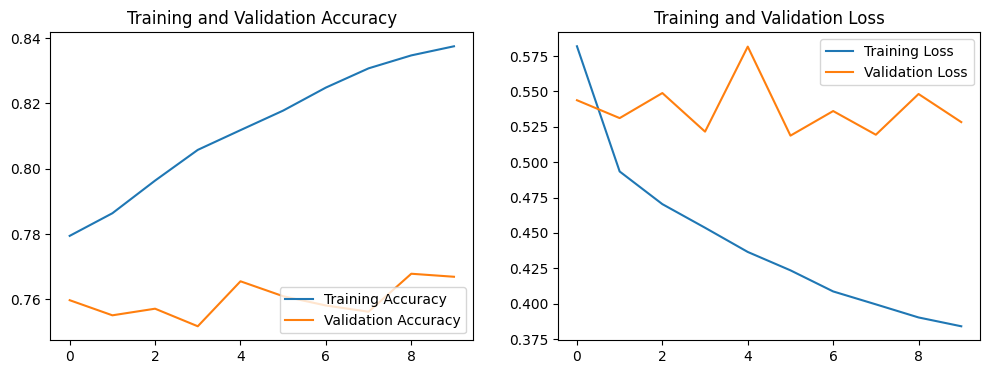

In [ ]:
# Plot training and validation accuracy over time
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


# --- Section 6: Save the Trained Model ---

In [ ]:
# Create a unique filename with a timestamp to avoid overwriting
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
model_filename = f'alzheimers_cnn_model_{timestamp}.h5'
model.save(model_filename)
print(f"\nModel saved successfully as: {model_filename}")


Model saved successfully as: alzheimers_cnn_model_20250823-130451.h5


# --- Section 7: Make a Prediction (Example) ---

In [ ]:
# Get a batch of images and labels from the validation generator
test_images, test_labels = next(validation_generator)
test_image = test_images[0]
true_label_index = np.argmax(test_labels[0])

# Expand dimensions to create a batch of 1 image
test_image = np.expand_dims(test_image, axis=0)

# Make a prediction
predictions = model.predict(test_image)
predicted_class_index = np.argmax(predictions)

print("\n--- Prediction Example ---")
print(f"True Class: {class_names[true_label_index]}")
print(f"Predicted Class: {class_names[predicted_class_index]}")
print(f"Prediction Probabilities: {predictions[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step

--- Prediction Example ---
True Class: Mild Dementia
Predicted Class: Non Demented
Prediction Probabilities: [2.5130384e-02 5.2607566e-04 6.9385695e-01 2.8048661e-01]
